In [2]:
#CELL 1 - Setup
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Research/glycemic-hybrid-ga

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

colors = {
    "GA-only": "blue",
    "GA+Rules": "red",
    "GA+Surrogate": "orange",
    "Hybrid": "green",
}

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Research/glycemic-hybrid-ga


In [3]:
# CELL 2 - Load summary
summary_path = "outputs/results/summary_all.csv"

df = pd.read_csv(summary_path)
df

,Scenario,Method,Fitness,BestTrueFitness,TIR,TBR,TAR,Gmin,Gmax,MeanG,StdG,CV,SevereHypo,SimCalls,DatasetSize,AUCsum,AUCmean,AUCregret
0,S1_normal,ga_only,99.374014,99.374014,100.000000,0.0,0.000000,92.877338,135.875743,110.822083,8.116355,7.323771,0,2400,-1,5954.712182,99.245203,9.581747
1,S1_normal,ga_rules,99.178881,99.178881,100.000000,0.0,0.000000,79.786971,139.775824,109.860057,11.720615,10.668678,0,2400,-1,5948.500595,99.141677,15.793334
2,S1_normal,ga_surrogate,99.404899,99.404899,100.000000,0.0,0.000000,88.296957,133.896006,110.213543,8.368179,7.592696,0,1752,1752,5952.006190,99.200103,12.287739
3,S1_normal,hybrid,99.222139,99.222139,100.000000,0.0,0.000000,80.164327,125.770374,107.744512,8.623141,8.003323,0,1752,1752,5952.268221,99.204470,12.025708
4,S2_ramadan,ga_only,98.904381,98.904381,100.000000,0.0,0.000000,71.724759,159.434062,108.942920,14.614990,13.415273,0,2400,-1,5926.712623,98.778544,13.568054
5,S2_ramadan,ga_rules,98.987936,98.987936,100.000000,0.0,0.000000,78.757416,165.565792,110.463753,14.119118,12.781675,0,2400,-1,5933.711249,98.895187,6.569429
6,S2_ramadan,ga_surrogate,98.939039,98.939039,100.000000,0.0,0.000000,86.148628,140.131364,114.400953,10.312367,9.014232,0,1752,1752,5936.342366,98.939039,3.938312
7,S2_ramadan,hybrid,99.004678,99.004678,100.000000,0.0,0.000000,77.622338,149.973937,110.375584,13.977348,12.663442,0,1752,1752,5924.634781,98.743913,15.645896
8,S3_stress_highcarb,ga_only,98.221204,98.221204,100.000000,0.0,0.000000,74.033752,152.682695,117.110293,17.653788,15.074498,0,2400,-1,5721.150903,95.352515,201.736015
9,S3_stress_highcarb,ga_rules,98.714782,98.714782,100.000000,0.0,0.000000,71.230041,143.352138,108.135026,16.405168,15.171003,0,2400,-1,5509.498811,91.824980,413.388107


In [4]:
# CELL 3 - Check available surrogate fields
print(df.columns)
df[["Scenario", "Method", "Fitness", "SimCalls", "DatasetSize"]]

Index(['Scenario', 'Method', 'Fitness', 'BestTrueFitness', 'TIR', 'TBR', 'TAR',
       'Gmin', 'Gmax', 'MeanG', 'StdG', 'CV', 'SevereHypo', 'SimCalls',
       'DatasetSize', 'AUCsum', 'AUCmean', 'AUCregret'],
      dtype='object')


,Scenario,Method,Fitness,SimCalls,DatasetSize
0,S1_normal,ga_only,99.374014,2400,-1
1,S1_normal,ga_rules,99.178881,2400,-1
2,S1_normal,ga_surrogate,99.404899,1752,1752
3,S1_normal,hybrid,99.222139,1752,1752
4,S2_ramadan,ga_only,98.904381,2400,-1
5,S2_ramadan,ga_rules,98.987936,2400,-1
6,S2_ramadan,ga_surrogate,98.939039,1752,1752
7,S2_ramadan,hybrid,99.004678,1752,1752
8,S3_stress_highcarb,ga_only,98.221204,2400,-1
9,S3_stress_highcarb,ga_rules,98.714782,2400,-1


In [5]:
# CELL 4 - Surrogate dataset size
surrogate_df = df[df["Method"].isin(["ga_surrogate", "hybrid"])].copy()

surrogate_df[["Scenario", "Method", "DatasetSize", "SimCalls"]]

,Scenario,Method,DatasetSize,SimCalls
2,S1_normal,ga_surrogate,1752,1752
3,S1_normal,hybrid,1752,1752
6,S2_ramadan,ga_surrogate,1752,1752
7,S2_ramadan,hybrid,1752,1752
10,S3_stress_highcarb,ga_surrogate,1752,1752
11,S3_stress_highcarb,hybrid,1752,1752
14,S4_exercise_lowcarb,ga_surrogate,1752,1752
15,S4_exercise_lowcarb,hybrid,1752,1752


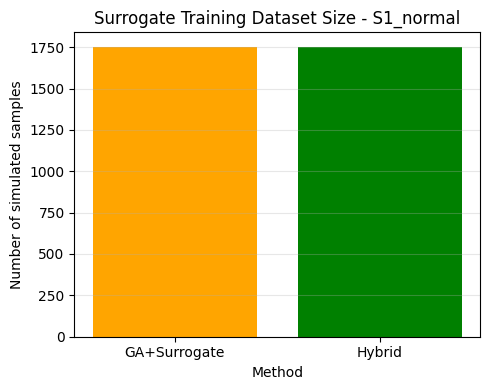

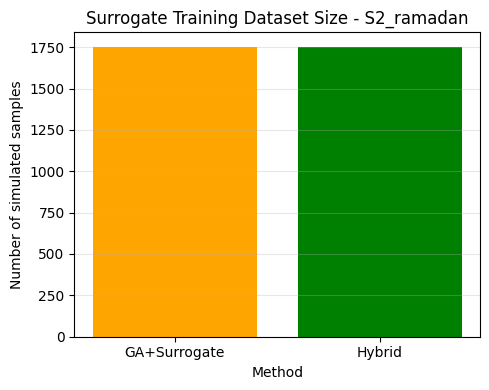

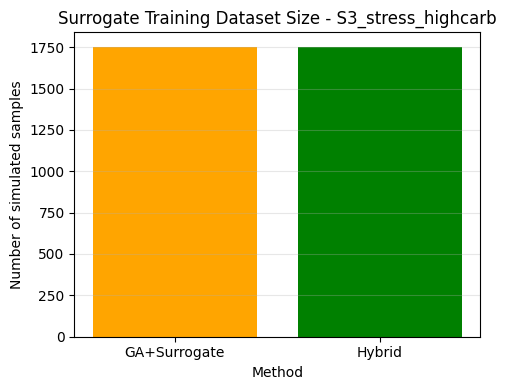

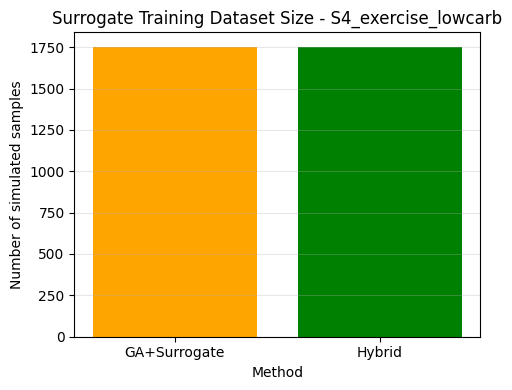

In [6]:
# CELL 5 - Dataset size plot
method_labels = {
    "ga_surrogate": "GA+Surrogate",
    "hybrid": "Hybrid"
}

surrogate_df["MethodLabel"] = surrogate_df["Method"].map(method_labels)

for scenario in surrogate_df["Scenario"].unique():
    subset = surrogate_df[surrogate_df["Scenario"] == scenario].copy()

    plt.figure(figsize=(5,4))
    plt.bar(
        subset["MethodLabel"],
        subset["DatasetSize"],
        color=[colors[m] for m in subset["MethodLabel"]]
    )

    plt.title(f"Surrogate Training Dataset Size - {scenario}")
    plt.ylabel("Number of simulated samples")
    plt.xlabel("Method")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [7]:
# CELL 6 - Simulation efficiency
avg_calls = df.groupby("Method")["SimCalls"].mean().reset_index()
avg_calls

,Method,SimCalls
0,ga_only,2400.0
1,ga_rules,2400.0
2,ga_surrogate,1752.0
3,hybrid,1752.0


In [8]:
# CELL 7 - Surrogate cost reduction
ga_calls = df[df["Method"] == "ga_only"]["SimCalls"].mean()
sur_calls = df[df["Method"] == "ga_surrogate"]["SimCalls"].mean()
hyb_calls = df[df["Method"] == "hybrid"]["SimCalls"].mean()

sur_reduction = (ga_calls - sur_calls) / ga_calls * 100
hyb_reduction = (ga_calls - hyb_calls) / ga_calls * 100

print(f"GA-only average calls: {ga_calls:.0f}")
print(f"GA+Surrogate average calls: {sur_calls:.0f}")
print(f"Hybrid average calls: {hyb_calls:.0f}")
print(f"GA+Surrogate reduction: {sur_reduction:.1f}%")
print(f"Hybrid reduction: {hyb_reduction:.1f}%")

GA-only average calls: 2400
GA+Surrogate average calls: 1752
Hybrid average calls: 1752
GA+Surrogate reduction: 27.0%
Hybrid reduction: 27.0%


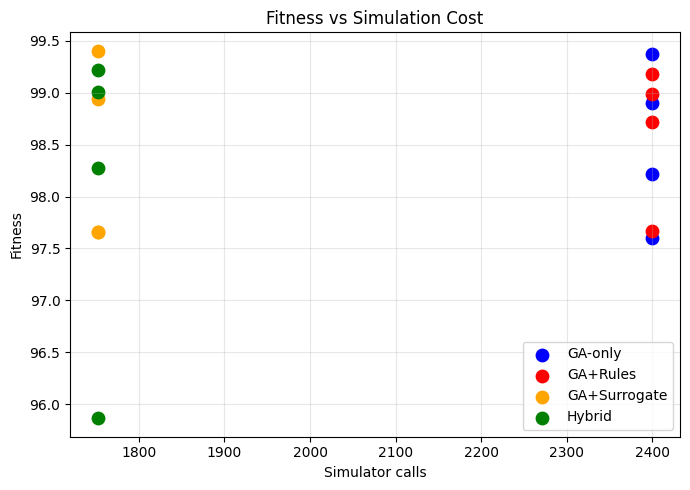

Saved: figures/fitness_vs_simulation_cost.pdf


In [9]:
# CELL 8 - Fitness vs simulation cost
method_labels_all = {
    "ga_only": "GA-only",
    "ga_rules": "GA+Rules",
    "ga_surrogate": "GA+Surrogate",
    "hybrid": "Hybrid"
}

df["MethodLabel"] = df["Method"].map(method_labels_all)

plt.figure(figsize=(7,5))

for method in ["GA-only", "GA+Rules", "GA+Surrogate", "Hybrid"]:
    subset = df[df["MethodLabel"] == method]
    plt.scatter(
        subset["SimCalls"],
        subset["Fitness"],
        label=method,
        color=colors[method],
        s=80
    )

plt.xlabel("Simulator calls")
plt.ylabel("Fitness")
plt.title("Fitness vs Simulation Cost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

out = "figures/fitness_vs_simulation_cost.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("Saved:", out)

In [10]:
#CELL 9 - Efficiency score
# Higher is better: fitness per 1000 simulator calls
df["EfficiencyScore"] = df["Fitness"] / (df["SimCalls"] / 1000.0)

eff_table = df[[
    "Scenario",
    "MethodLabel",
    "Fitness",
    "SimCalls",
    "EfficiencyScore"
]].copy()

eff_table = eff_table.sort_values(["Scenario", "EfficiencyScore"], ascending=[True, False])
eff_table

,Scenario,MethodLabel,Fitness,SimCalls,EfficiencyScore
2,S1_normal,GA+Surrogate,99.404899,1752,56.737956
3,S1_normal,Hybrid,99.222139,1752,56.633641
0,S1_normal,GA-only,99.374014,2400,41.405839
1,S1_normal,GA+Rules,99.178881,2400,41.324534
7,S2_ramadan,Hybrid,99.004678,1752,56.509519
6,S2_ramadan,GA+Surrogate,98.939039,1752,56.472054
5,S2_ramadan,GA+Rules,98.987936,2400,41.244973
4,S2_ramadan,GA-only,98.904381,2400,41.210159
11,S3_stress_highcarb,Hybrid,98.278060,1752,56.094783
10,S3_stress_highcarb,GA+Surrogate,97.658713,1752,55.741274


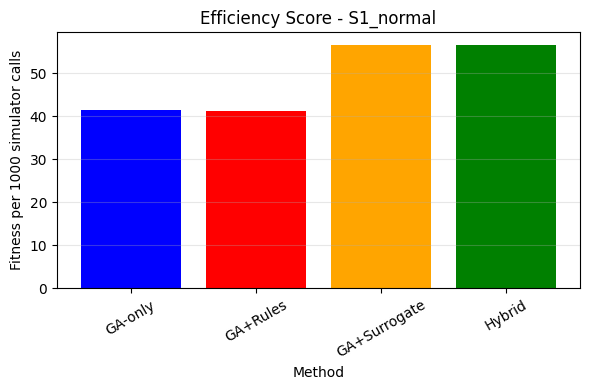

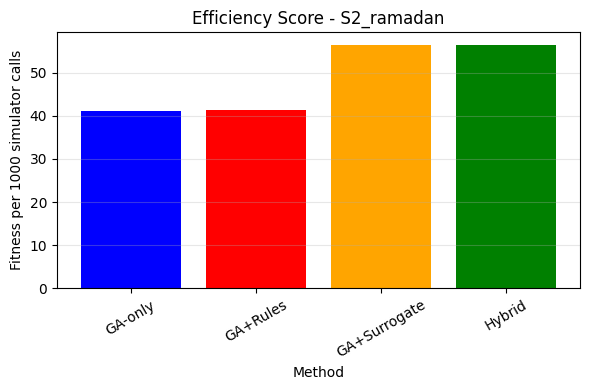

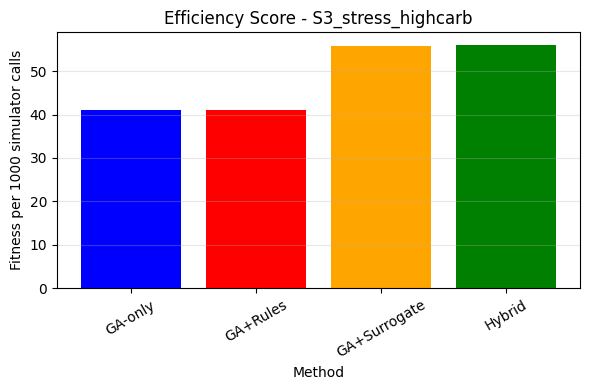

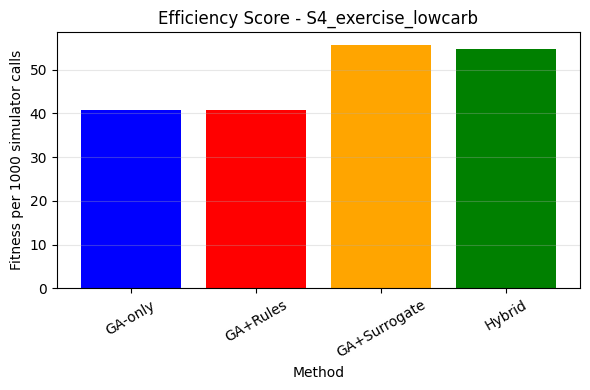

In [11]:
#CELL 10 - Efficiency score plot
method_order = ["GA-only", "GA+Rules", "GA+Surrogate", "Hybrid"]

for scenario in df["Scenario"].unique():
    subset = df[df["Scenario"] == scenario].copy()

    subset["MethodLabel"] = pd.Categorical(
        subset["MethodLabel"],
        categories=method_order,
        ordered=True
    )
    subset = subset.sort_values("MethodLabel")

    methods = subset["MethodLabel"].tolist()
    values = subset["EfficiencyScore"].tolist()

    plt.figure(figsize=(6,4))
    plt.bar(
        methods,
        values,
        color=[colors[m] for m in methods]
    )

    plt.title(f"Efficiency Score - {scenario}")
    plt.ylabel("Fitness per 1000 simulator calls")
    plt.xlabel("Method")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

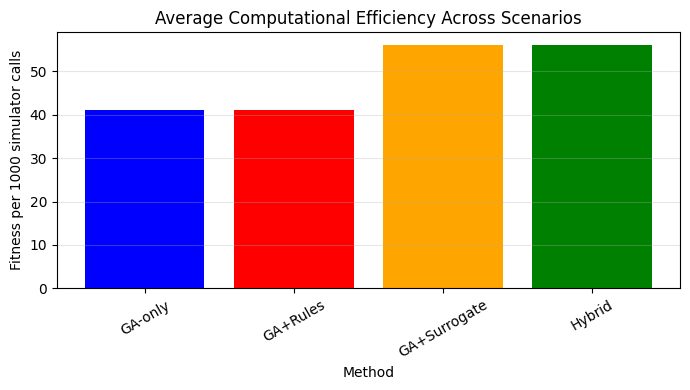

Saved: figures/average_efficiency_score.pdf


In [12]:
#CELL 11 - Save average efficiency figure
avg_eff = df.groupby("MethodLabel", as_index=False)["EfficiencyScore"].mean()

avg_eff["MethodLabel"] = pd.Categorical(
    avg_eff["MethodLabel"],
    categories=method_order,
    ordered=True
)
avg_eff = avg_eff.sort_values("MethodLabel")

methods = avg_eff["MethodLabel"].tolist()
values = avg_eff["EfficiencyScore"].tolist()

plt.figure(figsize=(7,4))
plt.bar(
    methods,
    values,
    color=[colors[m] for m in methods]
)

plt.title("Average Computational Efficiency Across Scenarios")
plt.ylabel("Fitness per 1000 simulator calls")
plt.xlabel("Method")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = "figures/average_efficiency_score.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("Saved:", out)

In [13]:
#CELL 12 - Surrogate-only vs Hybrid comparison
comparison = df[df["Method"].isin(["ga_surrogate", "hybrid"])][[
    "Scenario",
    "MethodLabel",
    "Fitness",
    "AUCregret",
    "SimCalls",
    "DatasetSize"
]].copy()

comparison

,Scenario,MethodLabel,Fitness,AUCregret,SimCalls,DatasetSize
2,S1_normal,GA+Surrogate,99.404899,12.287739,1752,1752
3,S1_normal,Hybrid,99.222139,12.025708,1752,1752
6,S2_ramadan,GA+Surrogate,98.939039,3.938312,1752,1752
7,S2_ramadan,Hybrid,99.004678,15.645896,1752,1752
10,S3_stress_highcarb,GA+Surrogate,97.658713,261.821950,1752,1752
11,S3_stress_highcarb,Hybrid,98.278060,88.379785,1752,1752
14,S4_exercise_lowcarb,GA+Surrogate,97.656148,253.205443,1752,1752
15,S4_exercise_lowcarb,Hybrid,95.864115,263.188304,1752,1752


In [14]:
#CELL 13 - Delta Hybrid vs GA+Surrogate
wide = comparison.pivot(index="Scenario", columns="MethodLabel", values=["Fitness", "AUCregret"])

wide["DeltaFitness_Hybrid_minus_Surrogate"] = (
    wide[("Fitness", "Hybrid")] - wide[("Fitness", "GA+Surrogate")]
)

wide["DeltaRegret_Hybrid_minus_Surrogate"] = (
    wide[("AUCregret", "Hybrid")] - wide[("AUCregret", "GA+Surrogate")]
)

wide

Fitness               AUCregret              \
MethodLabel         GA+Surrogate     Hybrid GA+Surrogate      Hybrid   
Scenario                                                               
S1_normal              99.404899  99.222139    12.287739   12.025708   
S2_ramadan             98.939039  99.004678     3.938312   15.645896   
S3_stress_highcarb     97.658713  98.278060   261.821950   88.379785   
S4_exercise_lowcarb    97.656148  95.864115   253.205443  263.188304   

                    DeltaFitness_Hybrid_minus_Surrogate  \
MethodLabel                                               
Scenario                                                  
S1_normal                                     -0.182760   
S2_ramadan                                     0.065639   
S3_stress_highcarb                             0.619348   
S4_exercise_lowcarb                           -1.792033   

                    DeltaRegret_Hybrid_minus_Surrogate  
MethodLabel                                             
Scenario                                                
S1_normal                                    -0.262031  
S2_ramadan                                   11.707585  
S3_stress_highcarb                         -173.442165  
S4_exercise_lowcarb                           9.982861

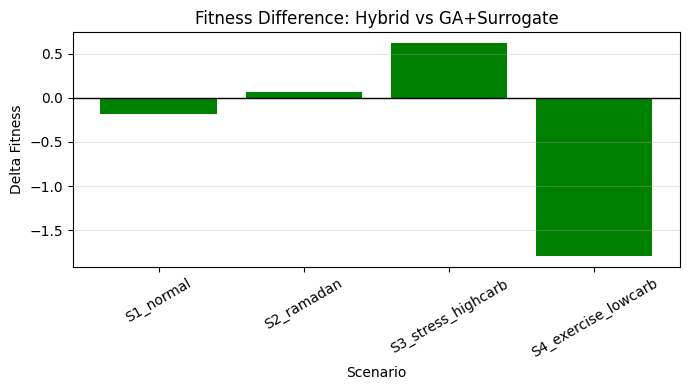

Saved: figures/delta_fitness_hybrid_vs_surrogate.pdf


In [15]:
#CELL 14 - Plot Hybrid vs GA+Surrogate fitness difference
delta = wide["DeltaFitness_Hybrid_minus_Surrogate"].reset_index()
delta.columns = ["Scenario", "DeltaFitness"]

plt.figure(figsize=(7,4))
plt.bar(delta["Scenario"], delta["DeltaFitness"], color="green")
plt.axhline(0, color="black", linewidth=1)

plt.title("Fitness Difference: Hybrid vs GA+Surrogate")
plt.ylabel("Delta Fitness")
plt.xlabel("Scenario")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = "figures/delta_fitness_hybrid_vs_surrogate.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("Saved:", out)

In [16]:
#CELL 15 - Export surrogate analysis table
sur_table = df[df["Method"].isin(["ga_surrogate", "hybrid"])][[
    "Scenario",
    "MethodLabel",
    "Fitness",
    "AUCregret",
    "SimCalls",
    "DatasetSize",
    "EfficiencyScore"
]].copy()

sur_table = sur_table.sort_values(["Scenario", "MethodLabel"])

latex = sur_table.to_latex(
    index=False,
    float_format="%.2f",
    caption="Surrogate-assisted optimization performance and computational efficiency.",
    label="tab:surrogate_analysis"
)

print(latex)

\begin{table}
\caption{Surrogate-assisted optimization performance and computational efficiency.}
\label{tab:surrogate_analysis}
\begin{tabular}{llrrrrr}
\toprule
Scenario & MethodLabel & Fitness & AUCregret & SimCalls & DatasetSize & EfficiencyScore \\
\midrule
S1_normal & GA+Surrogate & 99.40 & 12.29 & 1752 & 1752 & 56.74 \\
S1_normal & Hybrid & 99.22 & 12.03 & 1752 & 1752 & 56.63 \\
S2_ramadan & GA+Surrogate & 98.94 & 3.94 & 1752 & 1752 & 56.47 \\
S2_ramadan & Hybrid & 99.00 & 15.65 & 1752 & 1752 & 56.51 \\
S3_stress_highcarb & GA+Surrogate & 97.66 & 261.82 & 1752 & 1752 & 55.74 \\
S3_stress_highcarb & Hybrid & 98.28 & 88.38 & 1752 & 1752 & 56.09 \\
S4_exercise_lowcarb & GA+Surrogate & 97.66 & 253.21 & 1752 & 1752 & 55.74 \\
S4_exercise_lowcarb & Hybrid & 95.86 & 263.19 & 1752 & 1752 & 54.72 \\
\bottomrule
\end{tabular}
\end{table}

